In [111]:
# Cell 1: Imports and helper functions

import numpy as np
import matplotlib.pyplot as plt
import rasterio
from scipy.interpolate import griddata
from matplotlib.colors import LightSource

def load_dem(filename):
    with rasterio.open(filename) as src:
        dem = src.read(1)
        transform = src.transform
        x = np.arange(src.width) * transform.a + transform.c
        y = np.arange(src.height) * transform.e + transform.f
        y = y[::-1]  # flip y coordinates
        dem = np.flipud(dem)  # flip DEM vertically
        X, Y = np.meshgrid(x, y)
    return X, Y, dem

def calc_slope_histogram(dem, delta_x, delta_y, max_slope=90):
    h_x, h_y = np.gradient(dem, delta_x, delta_y)
    grad = np.sqrt(h_x**2 + h_y**2)
    slope_deg = np.degrees(np.arctan(grad)).flatten()
    bins = np.arange(0, max_slope + 1, 1)
    counts, _ = np.histogram(slope_deg, bins=bins)
    return bins[:-1], counts

# def extract_profile(X, Y, Z, line_pts, width=10):
#     """Extract a swath profile by averaging DEM values within 'width' around line_pts."""
#     # Flatten arrays for interpolation
#     points = np.column_stack((X.flatten(), Y.flatten()))
#     values = Z.flatten()

#     # Generate points along the profile line at fine intervals
#     dist = np.cumsum(np.r_[0, np.sqrt(np.diff([p[0] for p in line_pts])**2 + np.diff([p[1] for p in line_pts])**2)])
#     #num = int(dist[-1] / (X[0,1] - X[0,0]) * .1)  # 10x finer sampling
#     num = int(dist[-1] / (X[0,1] - X[0,0]))  # Match native grid resolution
#     xs = np.linspace(line_pts[0][0], line_pts[-1][0], num=num)
#     ys = np.linspace(line_pts[0][1], line_pts[-1][1], num=num)

#     profile_z = []
#     profile_dist = []
#     for xi, yi in zip(xs, ys):
#         idx = np.argmin((points[:,0] - xi)**2 + (points[:,1] - yi)**2)
#         profile_z.append(values[idx])
#         #dists = np.sqrt((points[:,0] - xi)**2 + (points[:,1] - yi)**2)
#         #within_width = values[dists <= width]
#         #if len(within_width) == 0:
#         #    profile_z.append(np.nan)
#         #else:
#         #    profile_z.append(np.nanmean(within_width))
#         profile_dist.append(np.sqrt((xi - xs[0])**2 + (yi - ys[0])**2))
#     return np.array(profile_dist), np.array(profile_z)

def extract_profile(X, Y, Z, line_pts):
    """Extract a profile along line_pts without smoothing."""
    points = np.column_stack((X.flatten(), Y.flatten()))
    values = Z.flatten()

    # Generate points along the profile line at native spacing
    dist = np.cumsum(np.r_[0, np.sqrt(np.diff([p[0] for p in line_pts])**2 + np.diff([p[1] for p in line_pts])**2)])
    num = int(dist[-1] / (X[0,1] - X[0,0]))  # match grid resolution
    xs = np.linspace(line_pts[0][0], line_pts[-1][0], num=num)
    ys = np.linspace(line_pts[0][1], line_pts[-1][1], num=num)

    profile_z = []
    profile_dist = []

    for xi, yi in zip(xs, ys):
        idx = np.argmin((points[:,0] - xi)**2 + (points[:,1] - yi)**2)
        profile_z.append(values[idx])
        profile_dist.append(np.sqrt((xi - xs[0])**2 + (yi - ys[0])**2))

    return np.array(profile_dist), np.array(profile_z)

In [112]:
# Cell 2: Load DEMs and fixed profile line

# Filenames
initial_file = 'E6.asc'
linear_file = 'e6_10m2linear.asc'
nonlinear_file = 'e6_10m2n0.5nonlinear.asc'

# Load DEMs
X, Y, initial = load_dem(initial_file)
_, _, linear = load_dem(linear_file)
_, _, nonlinear = load_dem(nonlinear_file)

# Adjustable sun angles
sun_azimuth = 300  # degrees (clockwise from north)
sun_altitude = 30  # degrees above horizon

# Fixed profile line endpoints (your coordinates)
line_pts = [(625843.949, 3599466.964), (625904.243, 3599493.325)]

# Y is flipped in load_dem, so Y[0, :] is top row, Y[-1, :] is bottom row
# Find the original max and min Y to flip the profile line y's accordingly

y_min = Y.min()
y_max = Y.max()

def flip_profile_line_y(line_pts, y_min, y_max):
    flipped_pts = []
    for x, y in line_pts:
        y_flipped = y_max - (y - y_min)
        flipped_pts.append((x, y_flipped))
    return flipped_pts

line_pts_flipped = flip_profile_line_y(line_pts, y_min, y_max)

# hillshade arrays
dx = X[0,1] - X[0,0]
dy = Y[1,0] - Y[0,0]

ls = LightSource(azdeg=sun_azimuth, altdeg=sun_altitude)

hillshade_initial = ls.hillshade(initial, vert_exag=1, dx=dx, dy=dy)
hillshade_linear = ls.hillshade(linear, vert_exag=1, dx=dx, dy=dy)
hillshade_nonlinear = ls.hillshade(nonlinear, vert_exag=1, dx=dx, dy=dy)
hillshade_min = min(hillshade_initial.min(), hillshade_linear.min(), hillshade_nonlinear.min())
hillshade_max = max(hillshade_initial.max(), hillshade_linear.max(), hillshade_nonlinear.max())


In [113]:
# Cell 3: Extract swath profiles and calculate slope histograms

#width = 10

dist_init, prof_init = extract_profile(X, Y, initial, line_pts)
_, prof_linear = extract_profile(X, Y, linear, line_pts)
_, prof_nonlinear = extract_profile(X, Y, nonlinear, line_pts)

bins, initial_counts = calc_slope_histogram(initial, X[0,1] - X[0,0], Y[1,0] - Y[0,0])
_, linear_counts = calc_slope_histogram(linear, X[0,1] - X[0,0], Y[1,0] - Y[0,0])
_, nonlinear_counts = calc_slope_histogram(nonlinear, X[0,1] - X[0,0], Y[1,0] - Y[0,0])


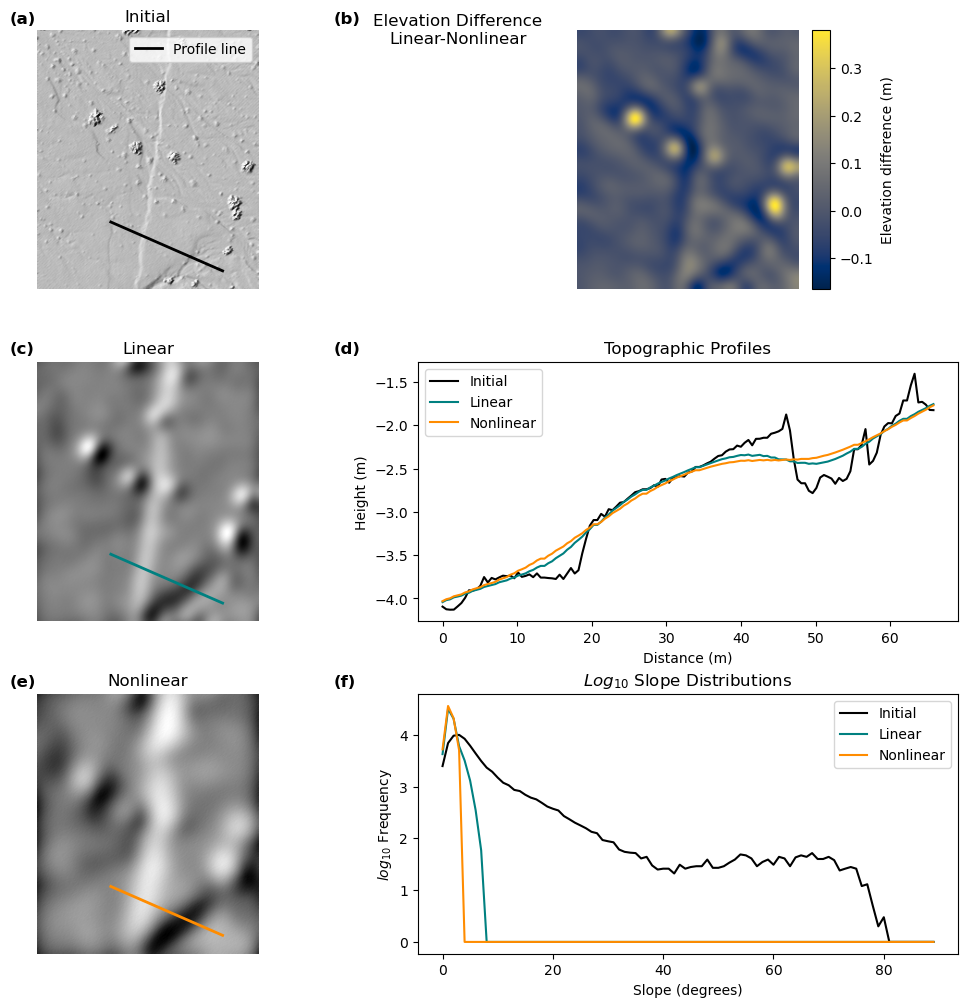

In [114]:
# Cell 4: Plot all figures together


fig, axs = plt.subplots(3, 2, figsize=(12, 12), gridspec_kw={'wspace': 0.0, 'hspace': 0.28})



axs[0, 0].imshow(hillshade_initial, cmap='gray', 
                 extent=[X.min(), X.max(), Y.min(), Y.max()],
                 vmin=hillshade_min, vmax=hillshade_max)
axs[0, 0].set_title('Initial')
axs[0, 0].axis('off')

axs[1, 0].imshow(hillshade_linear, cmap='gray', 
                 extent=[X.min(), X.max(), Y.min(), Y.max()],
                 vmin=hillshade_min, vmax=hillshade_max)
axs[1, 0].set_title('Linear')
axs[1, 0].axis('off')

axs[2, 0].imshow(hillshade_nonlinear, cmap='gray', 
                 extent=[X.min(), X.max(), Y.min(), Y.max()],
                 vmin=hillshade_min, vmax=hillshade_max)
axs[2, 0].set_title('Nonlinear')
axs[2, 0].axis('off')

im = axs[0, 1].imshow(linear - nonlinear, cmap='cividis', 
                      extent=[X.min(), X.max(), Y.min(), Y.max()])

axs[0, 1].axis('off')
#axs[0, 1].set_xlim(625800, 625920)
#axs[0, 1].set_xlabel('Easting (m)')
#axs[0, 1].set_ylabel('Northing (m)')
axs[0, 1].text(-.54, 1, 'Elevation Difference\nLinear-Nonlinear',
               fontsize=12,
               rotation=0, va='center', ha='center', transform=axs[0, 1].transAxes)
#axs[0, 1].set_title('Elevation Difference Linear-Nonlinear (10 $m^2$ n=0.5)')

# ⬅️ Shift axs[0,1] left
pos = axs[0, 1].get_position()
axs[0, 1].set_position([pos.x0 - 0.1, pos.y0, pos.width, pos.height])



# Define a new axis for the colorbar, aligned to the right of axs[0,1]
cax = fig.add_axes([pos.x1 + 0.03, pos.y0, 0.015, pos.height])
# [left, bottom, width, height] in figure coords (0 to 1)

# Add colorbar in separate axis
cbar = fig.colorbar(im, cax=cax)
cbar.set_label('Elevation difference (m)', labelpad=5)


# Plot profile line on DEM plots with flipped Y coords
colors = ['black', 'teal', 'darkorange']
for i, (ax, color) in enumerate(zip([axs[0, 0], axs[1, 0], axs[2, 0]], colors)):
    ax.plot([pt[0] for pt in line_pts_flipped], [pt[1] for pt in line_pts_flipped], 
            color=color, linewidth=2, label='Profile line')
    if i == 0:  # Only add legend on the first subplot
        ax.legend()

# Topographic profiles plot
ax_prof = axs[1, 1]
ax_prof.plot(dist_init, prof_init, 'k-', label='Initial')
ax_prof.plot(dist_init, prof_linear, color='teal', label='Linear')
ax_prof.plot(dist_init, prof_nonlinear, color='darkorange', label='Nonlinear')
ax_prof.set_xlabel('Distance (m)')
ax_prof.set_ylabel('Height (m)')
ax_prof.set_title('Topographic Profiles')
ax_prof.legend()

ax_hist = axs[2, 1]
ax_hist.plot(bins, np.log10(initial_counts + 1), 'k-', label='Initial')
ax_hist.plot(bins, np.log10(linear_counts + 1), color='teal', label='Linear')
ax_hist.plot(bins, np.log10(nonlinear_counts + 1), color='darkorange', label='Nonlinear')
ax_hist.set_xlabel('Slope (degrees)')
ax_hist.set_ylabel('$log_{10}$ Frequency')
ax_hist.set_title('$Log_{10}$ Slope Distributions')
ax_hist.legend()



labels = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)']
positions = [
    (0.16, 0.895),  # (a) - top-left
    (0.43, 0.895),  # (b) - top-right
    (0.16, 0.62),  # (c)
    (0.43, 0.62),  # (d)
    (0.16, 0.343),  # (e)
    (0.43, 0.343)   # (f)
]

for label, (x, y) in zip(labels, positions):
    fig.text(x, y, label, fontsize=12, fontweight='bold', ha='left', va='top')


fig.subplots_adjust(left=0.05, right=0.95)
plt.show()